# Train Commutative Transformer

This notebook intentionally keeps orchestration thin. Split preparation, fitting, reporting, plotting, and persistence are delegated to shared utilities in `src.ml`.


In [2]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_holdout_branch_embedding_projections,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from src.ml import CommutativeTransformerClassifier, CommutativeTransformerConfig


In [4]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
print(dataset_artifact_path.name)
experiment_output_dir = Path("artifacts/nb8_commutative_transformer")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0

model_config = CommutativeTransformerConfig(
    spatial_patch_size_st=(1, 16, 16),
    spatial_patch_size_ts=(1, 16, 16),
    temporal_patch_size_ts=1,
    embed_dim=96,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.2,
    attention_dropout=0.0,
    st_spatial_depth=2,
    st_temporal_depth=2,
    ts_temporal_depth=2,
    ts_spatial_depth=2,
    embedding_dim=96,
    num_prototypes=32,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=1e-4,
    weight_decay=1e-3,
    early_stopping_patience=12,
    early_stopping_min_delta=1e-3,
    scheduler_patience=4,
    scheduler_factor=0.7,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.2,
    concentration_weight=0.2,
    consistency_weight=0.2,
    feature_weight=0.05,
    prototype_temperature=0.1,
)


moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y64_x64.pt


In [5]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)


In [6]:
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)


In [7]:
display_experiment_summary(experiment)


,split,n_samples
0,train_augmented,1169
1,train_base,167
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Bemegride,control,49
1,GABAAR_Antagonist,Gabazine,high,49
2,GABAAR_Antagonist,Gabazine,control,42
3,NMDAR_Activation,Cis-ACPD,control,42
4,AChE_Inhibitor_Reversible,Galantamine,high,42
5,mAChR_Agonist_NonSelective,Bethanechol,high,42
6,mAChR_Agonist_NonSelective,Bethanechol,mid,42
7,GABAAR_Antagonist,Bicuculline,mid,35
8,NMDAR_Activation,Cis-ACPD,mid,35
9,NMDAR_Activation,N-methyl-D-aspartate,high,35


In [8]:
model = CommutativeTransformerClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
)


In [9]:
fit_estimator_on_experiment(model, experiment)


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 2.00e-04   4:29:30 |   3.9722   1.5423   3.4261   0.0347   2.4728   1.0944 |   3.8827   1.5360   3.2933   0.0119   2.4005   1.0938
002/100 2.00e-04   4:24:32 |   3.8543   1.4691   3.4057   0.0331   2.3134   1.0821 |   3.8793   1.5283   3.3432   0.0186   2.3010   1.0865
003/100 2.00e-04   4:13:17 |   3.8091   1.4310   3.4400   0.0446   2.1934   1.0745 |   3.8319   1.4830   3.3800   0.0145   2.2122   1.0752
004

,spatial_patch_size_st,"(1, ...)"
,spatial_patch_size_ts,"(1, ...)"
,temporal_patch_size_ts,1
,embed_dim,96
,num_heads,4
,mlp_ratio,4.0
,dropout,0.2
,attention_dropout,0.0
,st_spatial_depth,2
,st_temporal_depth,2
,ts_temporal_depth,2


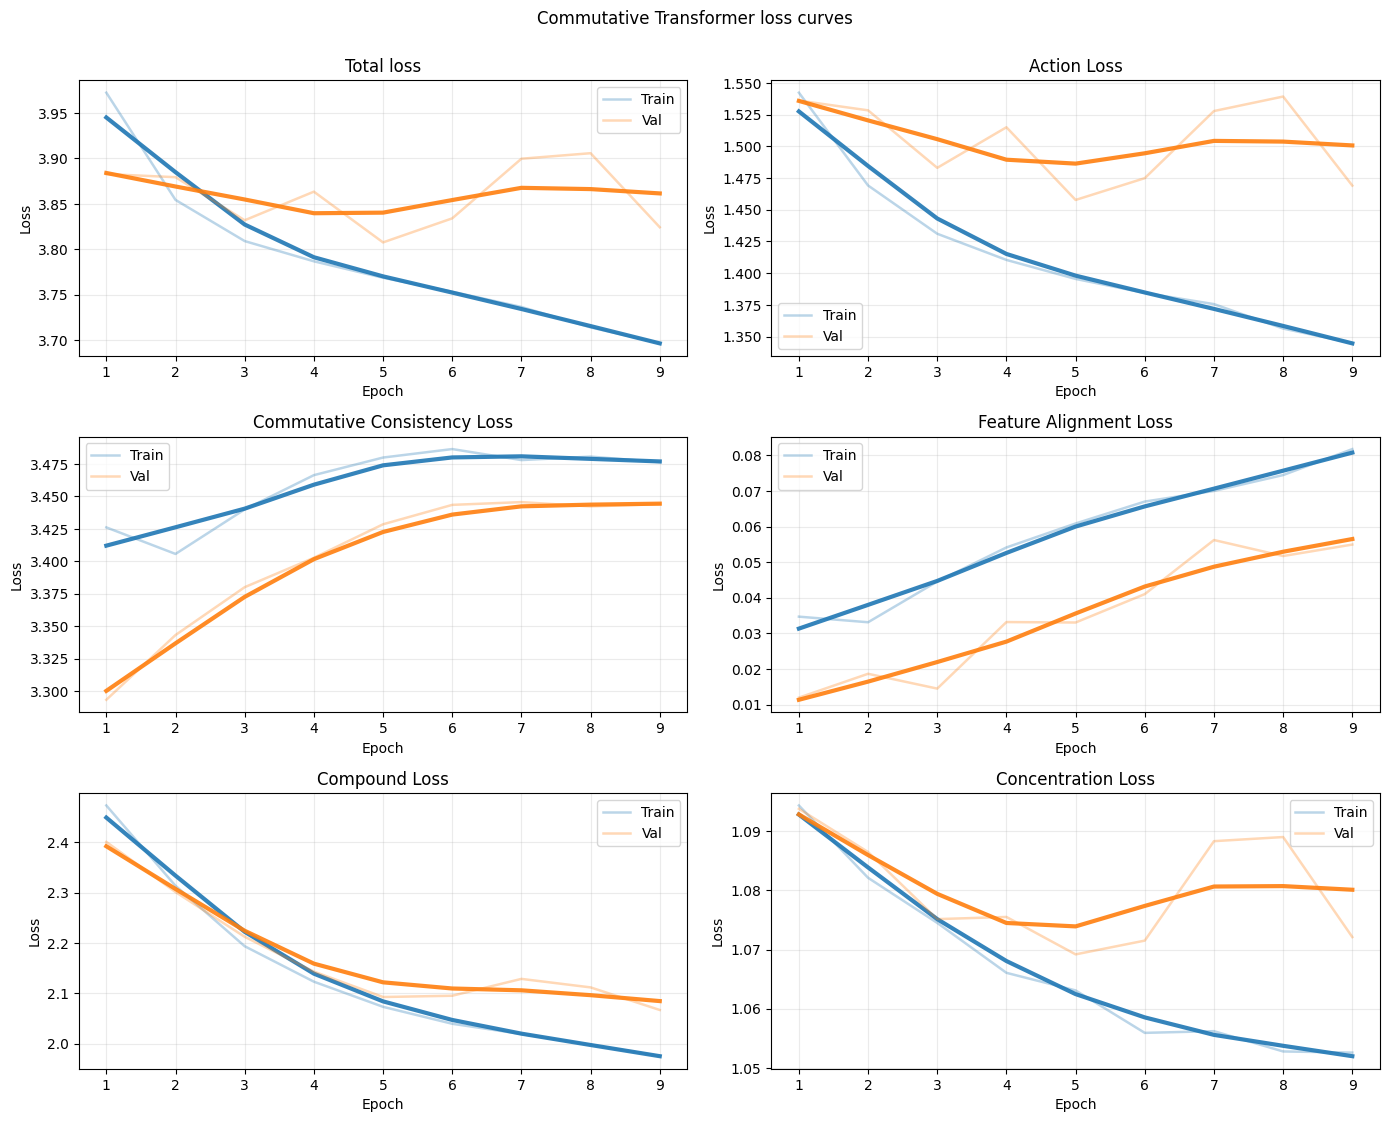

In [10]:
plot_training_history(model, title="Commutative Transformer loss curves", loess_frac=0.6);



## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.380952,1.000000,0.551724,24.0
GABAAR_Antagonist,1.000000,0.166667,0.285714,12.0
NMDAR_Activation,0.800000,0.400000,0.533333,10.0
AChE_Inhibitor_Reversible,0.000000,0.000000,0.000000,12.0
mAChR_Agonist_NonSelective,0.000000,0.000000,0.000000,12.0


,value
accuracy,0.428571
macro_precision,0.436190
macro_recall,0.313333
macro_f1,0.274154
weighted_precision,0.416327
weighted_recall,0.428571
weighted_f1,0.314333
n_samples,70.000000
roc_auc_ovr_macro,0.656438
average_precision_macro,0.433828


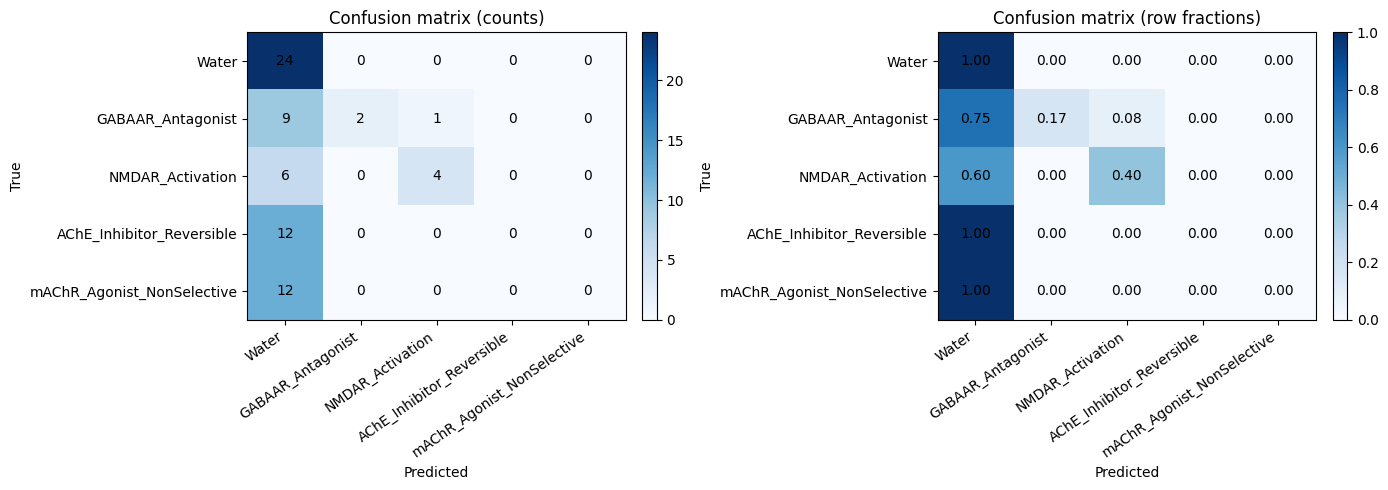


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.369231,1.000000,0.539326,24.0
Bemegride,0.000000,0.000000,0.000000,6.0
Bicuculline,0.000000,0.000000,0.000000,3.0
Gabazine,0.000000,0.000000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,1.000000,0.333333,0.500000,3.0
Cis-ACPD,0.000000,0.000000,0.000000,3.0
N-methyl-D-aspartate,0.750000,0.750000,0.750000,4.0
Donepezil,0.000000,0.000000,0.000000,4.0
Galantamine,0.000000,0.000000,0.000000,4.0


,value
accuracy,0.400000
macro_precision,0.163018
macro_recall,0.160256
macro_f1,0.137640
weighted_precision,0.212308
weighted_recall,0.400000
weighted_f1,0.249197
n_samples,70.000000
roc_auc_ovr_macro,0.593402
average_precision_macro,0.200556


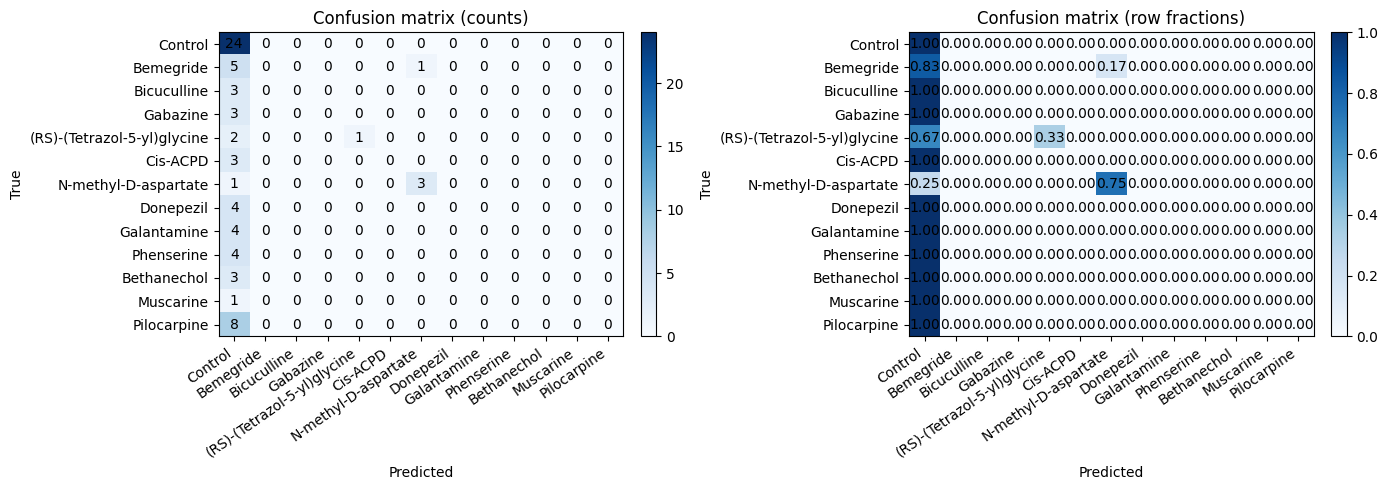


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.400000,0.916667,0.556962,24.0
high,0.533333,0.320000,0.400000,25.0
mid,0.000000,0.000000,0.000000,21.0


,value
accuracy,0.428571
macro_precision,0.311111
macro_recall,0.412222
macro_f1,0.318987
weighted_precision,0.327619
weighted_recall,0.428571
weighted_f1,0.333816
n_samples,70.000000
roc_auc_ovr_macro,0.624323
average_precision_macro,0.494910


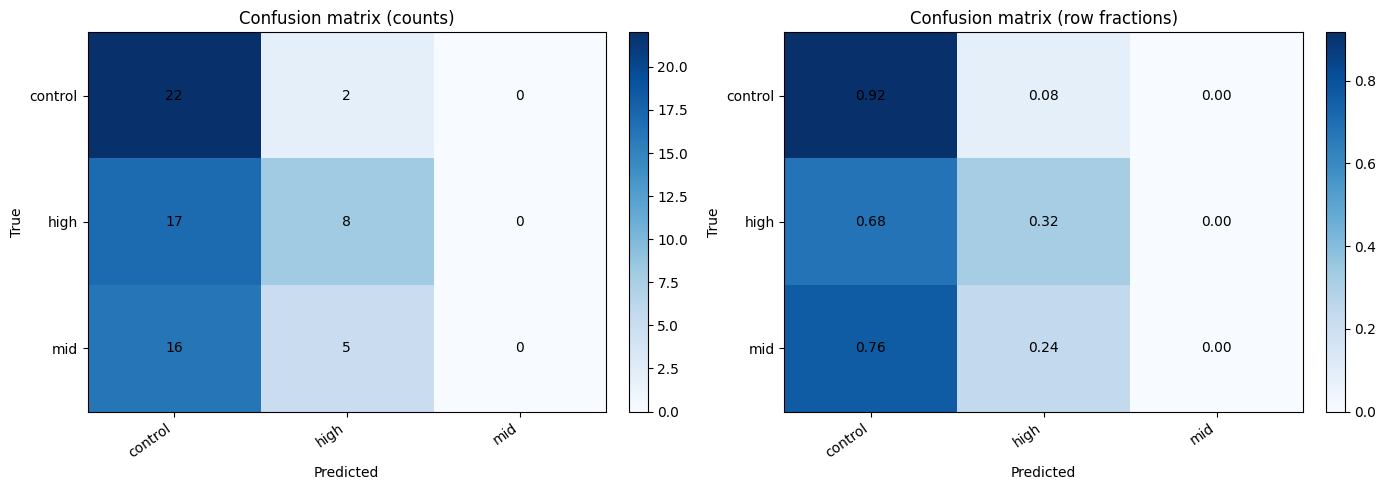

In [11]:
holdout_evaluation = display_holdout_evaluation(model, experiment)


/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

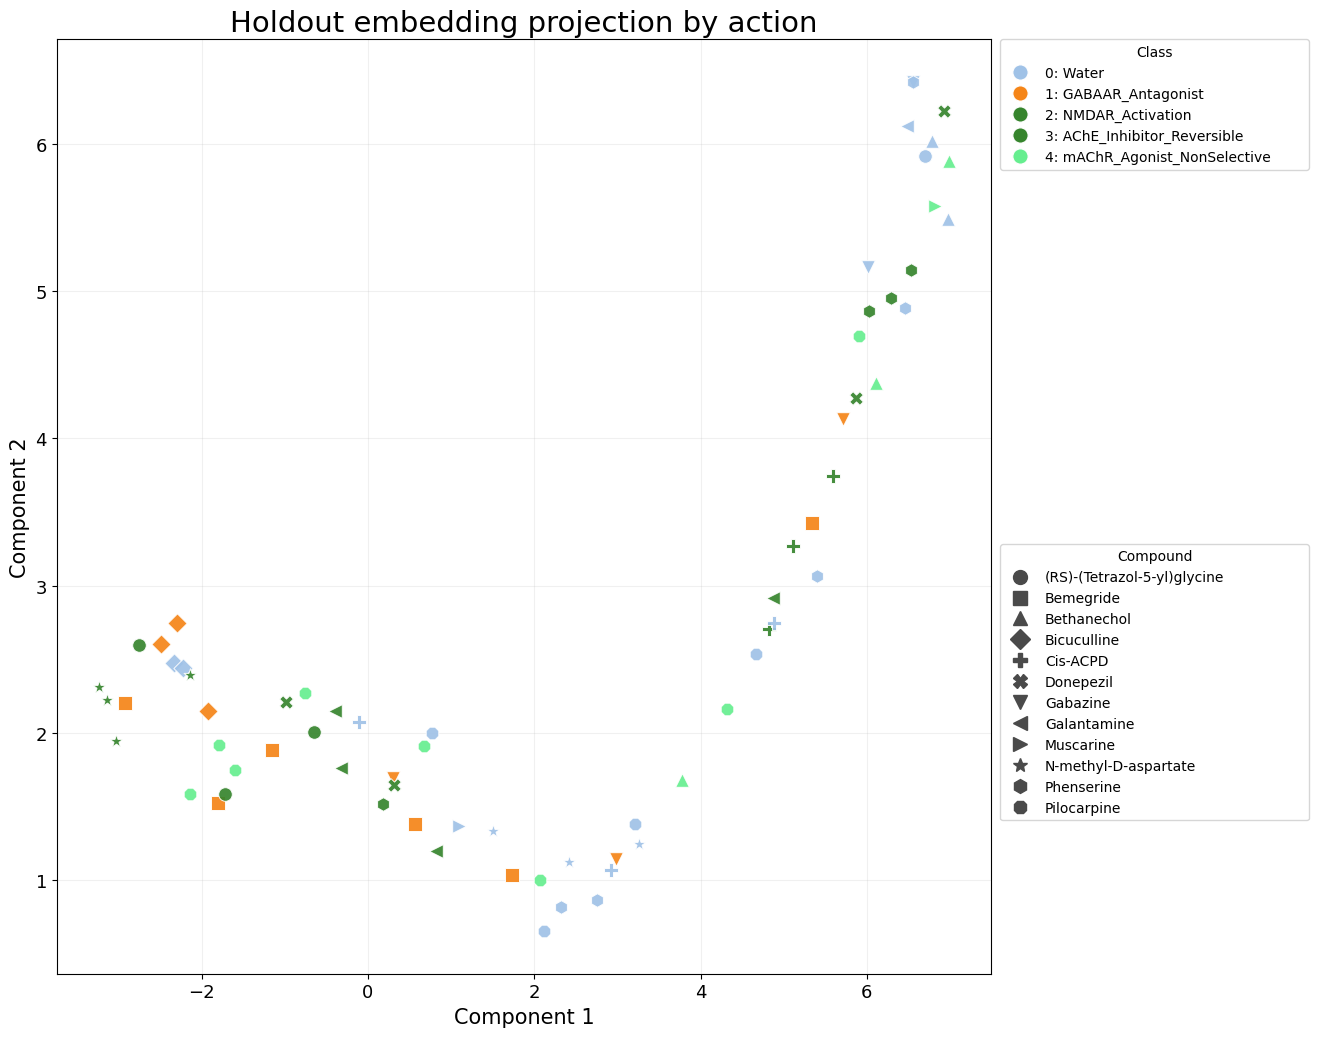

In [12]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)


In [13]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}


In [14]:
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
